In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
dataset=pd.read_csv('E:\Main -- Project\Customer Churn Dataset\Data\WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
dataset.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [4]:
dataset.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
dataset.drop_duplicates(inplace=True)

In [6]:
dataset.shape

(7043, 21)

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
dataset['TotalCharges']=dataset['TotalCharges'].replace(' ' ,np.nan)

In [9]:
dataset['TotalCharges']=dataset['TotalCharges'].astype('float')

In [10]:
dataset['TotalCharges']=dataset['TotalCharges'].fillna(dataset['TotalCharges'].mean())

In [11]:
for i in dataset.select_dtypes('object'):
    dataset[i]=   dataset[i].replace("No internet service" , "NO")

In [12]:
dataset['MultipleLines']=dataset['MultipleLines'].replace("No phone service" , "No")
dataset['MultipleLines']=dataset['MultipleLines'].replace("No phone service" , "No")

In [13]:
dataset['SeniorCitizen']=dataset['SeniorCitizen'].replace( [1,0], ['Yes' ,'No'])

In [14]:
dataset.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2265.000258
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1400.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [15]:
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data Visualization

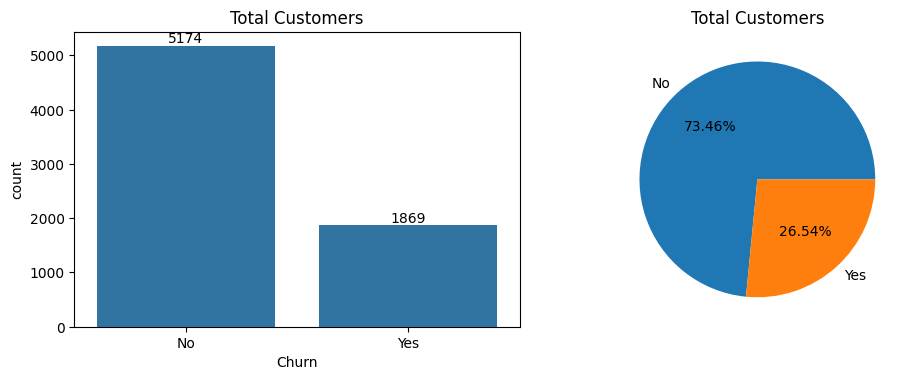

In [16]:
plt.figure(figsize=(10,7))
plt.subplot(2,2,1)
plt.title('Total Customers')
ax=sns.countplot(data=dataset ,x='Churn')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.subplot(2,2,2)
gb=dataset.groupby('Churn').agg({'Churn':'count'})
plt.pie(gb['Churn'],labels=gb.index ,autopct='%1.2f%%')
plt.title('Total Customers')
plt.show()

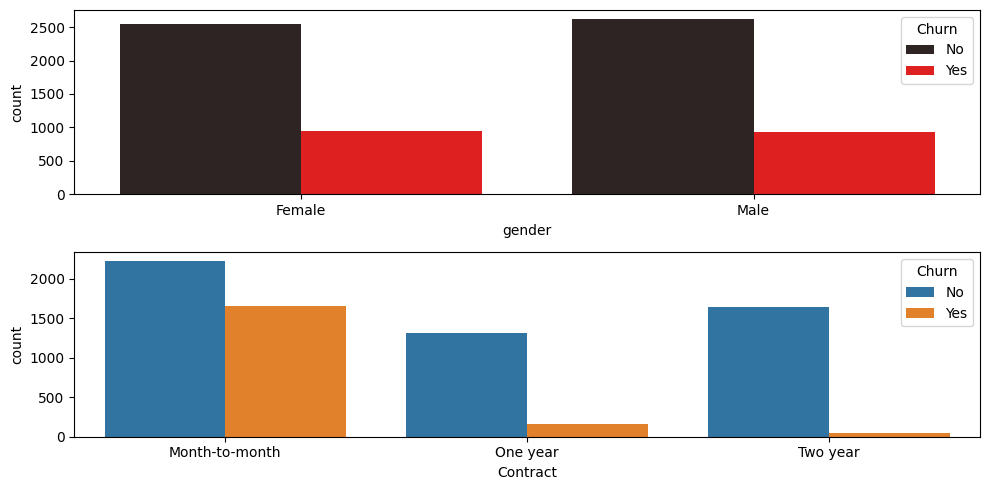

In [17]:
plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
sns.countplot(data=dataset , x='gender' ,color='red' ,hue='Churn')
plt.tight_layout()
plt.subplot(2,1,2)
sns.countplot(data=dataset ,x='Contract' ,hue='Churn')
plt.tight_layout()

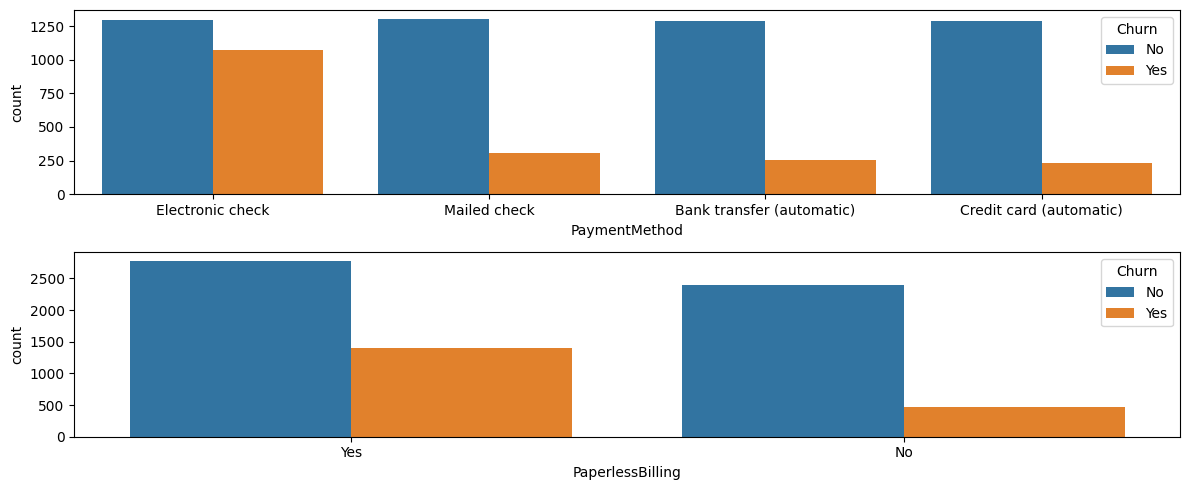

In [18]:
plt.figure(figsize=(12,5))
plt.subplot(2,1,1)
sns.countplot(data=dataset ,x='PaymentMethod',hue='Churn')
plt.tight_layout()
plt.subplot(2,1,2)
sns.countplot(data=dataset ,x='PaperlessBilling',hue='Churn')
plt.tight_layout()
plt.show()

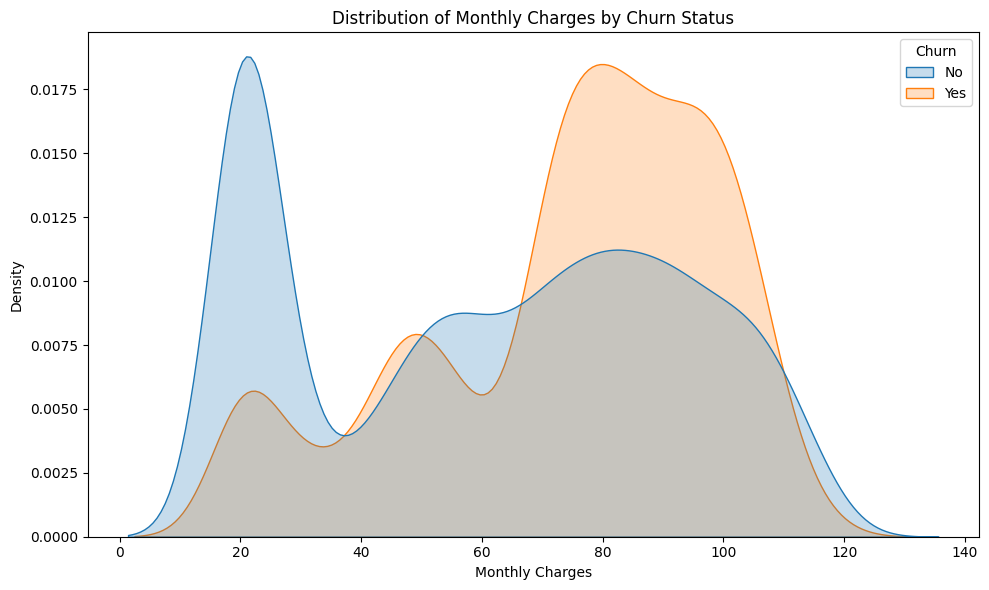

In [19]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=dataset, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False)
plt.title('Distribution of Monthly Charges by Churn Status')
plt.xlabel('Monthly Charges')
plt.ylabel('Density')
plt.tight_layout()

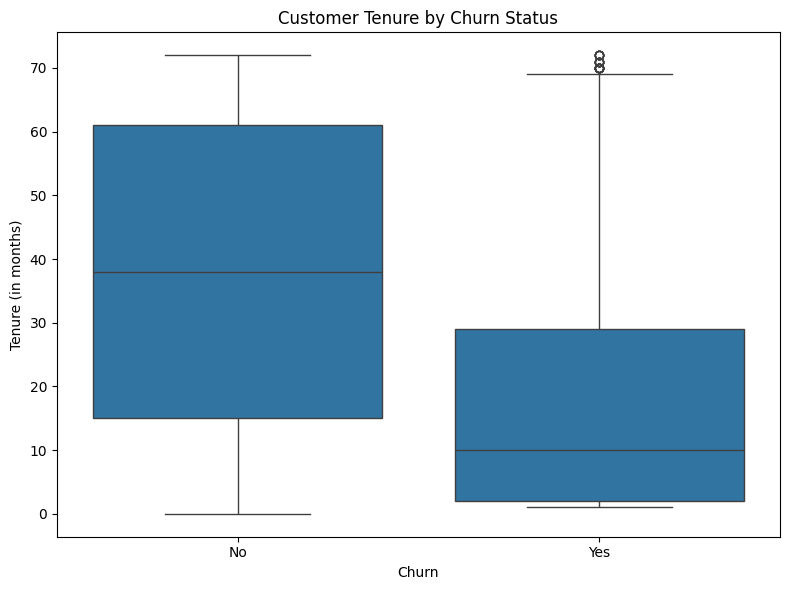

In [20]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='tenure', data=dataset)
plt.title('Customer Tenure by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (in months)')
plt.tight_layout()
plt.show()

### Feature Extraction from Dataset

In [21]:
dataset['TotalCharges']=dataset['TotalCharges'].replace(' ' , np.nan)
dataset['TotalCharges']=dataset['TotalCharges'].astype('float')

In [22]:
# 1. Prevent division by zero for brand new customers (tenure = 0)
dataset['tenure_safe'] =dataset['tenure'].replace(0, 1)

# 2. Calculate their historical average monthly bill
dataset['avg_historical_charge'] = dataset['TotalCharges'] / dataset['tenure_safe']

# 3. The Delta: Are they paying more NOW than their historical average?
# A highly positive number indicates a recent price hike or added services.
# Sudden price spikes are massive churn triggers.
dataset['charge_spike'] = dataset['MonthlyCharges'] - dataset['avg_historical_charge']

In [23]:
 # High monthly cost divided by low tenure yields a very high number.
# This creates a single continuous feature that isolates your most vulnerable demographic.
dataset['cost_to_loyalty_ratio'] = dataset['MonthlyCharges'] / dataset['tenure_safe']

In [24]:
# Assuming you have a 'contract' column with a 'Month-to-month' value
# 1. Isolate the highest risk contract type as a binary (1 or 0)
dataset['is_month_to_month'] = (dataset['Contract'] == 'Month-to-month').astype(int)

# 2. Multiply the contract risk by the financial burden
# This results in $0 for locked contracts, and the full bill amount for month-to-month.
dataset['m2m_flight_risk'] = dataset['is_month_to_month'] * dataset['MonthlyCharges']

## Model Creation Buliding

In [25]:
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier ,AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder ,StandardScaler , OneHotEncoder
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
import xgboost as xgb
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

In [26]:
dataset.drop('customerID' , axis=1 , inplace=True)

In [27]:
input_data=dataset.drop('Churn',axis=1)
output=dataset['Churn']

In [28]:
Le=LabelEncoder()
output_en=Le.fit_transform(output)

In [42]:
categorical_cols=['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod' ,'SeniorCitizen']
numerical_cols=['charge_spike' ,'MonthlyCharges','TotalCharges','tenure','avg_historical_charge' ,'tenure_safe' ,'cost_to_loyalty_ratio' ,'is_month_to_month' ,'m2m_flight_risk']

In [43]:
dataset.select_dtypes('float')

,MonthlyCharges,TotalCharges,avg_historical_charge,charge_spike,cost_to_loyalty_ratio,m2m_flight_risk
0,29.85,29.85,29.850000,0.000000,29.850000,29.85
1,56.95,1889.50,55.573529,1.376471,1.675000,0.00
2,53.85,108.15,54.075000,-0.225000,26.925000,53.85
3,42.30,1840.75,40.905556,1.394444,0.940000,0.00
4,70.70,151.65,75.825000,-5.125000,35.350000,70.70
...,...,...,...,...,...,...
7038,84.80,1990.50,82.937500,1.862500,3.533333,0.00
7039,103.20,7362.90,102.262500,0.937500,1.433333,0.00
7040,29.60,346.45,31.495455,-1.895455,2.690909,29.60
7041,74.40,306.60,76.650000,-2.250000,18.600000,74.40


In [44]:
preprocesser=ColumnTransformer(transformers=[
    ('cat' ,OneHotEncoder(),categorical_cols),
    ('num',StandardScaler() ,numerical_cols)
])

In [45]:
X_train, X_test, y_train, y_test = train_test_split(input_data, output_en, test_size=0.2, random_state=42)

In [46]:
pipeline_Lr=Pipeline([
    ('pr' , preprocesser),
    ('sm' , SMOTE()) ,
    ('Lr',LogisticRegression(random_state=42,class_weight='balanced'))
]
)

In [47]:
pipeline_Dtr=Pipeline([
    ('pr' , preprocesser),
    ('sm' , SMOTE()),
    ('Dtr',DecisionTreeClassifier(random_state=42,class_weight='balanced'))
]
)

In [48]:
pipeline_Rdf=Pipeline([
    ('pr' , preprocesser),
    ('sm' , SMOTE()),
    ('Rdf',RandomForestClassifier(random_state=42,class_weight='balanced'))
]
)

In [49]:
pipeline_ada=Pipeline([
    ('pr' , preprocesser),
    ('sm' , SMOTE()),
    ('Ada',AdaBoostClassifier(random_state=42))
]
)

In [50]:
pipeline_knn=Pipeline([
    ('pr' , preprocesser),
    ('sm' , SMOTE()),
    ('knn',KNeighborsClassifier())
]
)

In [51]:
pipeline_svm=Pipeline([
    ('pr' , preprocesser),
        ('sm' , SMOTE()),
    ('svm',SVC(class_weight='balanced'))
]
)

In [52]:
pipeline_xgb=Pipeline([
    ('pr' , preprocesser),
    ('sm' , SMOTE()),
    ('xbg',xgb.XGBClassifier())
]
)

## Logistic Regression Model

In [53]:
pipeline_Lr.fit(X_train,y_train)

,steps,"[('pr', ...), ('sm', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [54]:
print('Logistic Regression Classification Report:')
print(classification_report(y_test, pipeline_Lr.predict(X_test)))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.75      0.82      1036
           1       0.54      0.82      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.76      0.78      1409



In [65]:
# 1. Set a STRICTER threshold to fix your low precision
threshold_value = 0.675

# 2. Extract ONLY the probabilities for Class 1 using [:, 1]
prob_pred_class1 = pipeline_Lr.predict_proba(X_test)[:, 1]

# 3. Apply the correct logic and convert boolean True/False to 1/0
ada_pred_adjusted = (prob_pred_class1 >= threshold_value).astype(int)

In [66]:
print('Logistic Regression Classification Report:')
print(classification_report(y_test, ada_pred_adjusted))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1036
           1       0.64      0.64      0.64       373

    accuracy                           0.81      1409
   macro avg       0.75      0.75      0.75      1409
weighted avg       0.81      0.81      0.81      1409



### Decison Tree Classifier

In [67]:
pipeline_Dtr.fit(X_train, y_train)

,steps,"[('pr', ...), ('sm', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [68]:
print('Decision Tree Classification Report:')
print(classification_report(y_test, pipeline_Dtr.predict(X_test)))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.79      0.81      1036
           1       0.50      0.59      0.54       373

    accuracy                           0.73      1409
   macro avg       0.67      0.69      0.68      1409
weighted avg       0.75      0.73      0.74      1409



### Random Forest Classifier

In [69]:
pipeline_Rdf.fit(X_train, y_train)
print('Random Forest Classification Report:')
print(classification_report(y_test, pipeline_Rdf.predict(X_test)))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1036
           1       0.61      0.59      0.60       373

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409



### ADA BOOSTING CLASSIFIER

In [70]:
pipeline_ada.fit(X_train, y_train)
print('AdaBoost Classification Report:')
print(classification_report(y_test, pipeline_ada.predict(X_test)))

AdaBoost Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.76      0.83      1036
           1       0.54      0.77      0.63       373

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409



In [88]:
# 1. Set a STRICTER threshold to fix your low precision
threshold_value = 0.535

# 2. Extract ONLY the probabilities for Class 1 using [:, 1]
prob_pred_class1 = pipeline_ada.predict_proba(X_test)[:, 1]

# 3. Apply the correct logic and convert boolean True/False to 1/0
ada_pred_adjusted = (prob_pred_class1 >= threshold_value).astype(int)

In [89]:
print('ADA Boost' ,classification_report(y_test, ada_pred_adjusted))

ADA Boost               precision    recall  f1-score   support

           0       0.87      0.87      0.87      1036
           1       0.63      0.64      0.63       373

    accuracy                           0.81      1409
   macro avg       0.75      0.75      0.75      1409
weighted avg       0.81      0.81      0.81      1409



### K-Nearest Neigbor

In [73]:
pipeline_knn.fit(X_train, y_train)
print('KNeighbors Classification Report:')
print(classification_report(y_test, pipeline_knn.predict(X_test)))

KNeighbors Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.68      0.77      1036
           1       0.46      0.76      0.57       373

    accuracy                           0.70      1409
   macro avg       0.67      0.72      0.67      1409
weighted avg       0.77      0.70      0.71      1409



### Support Vector Machine

In [74]:
pipeline_svm.fit(X_train, y_train)
print('SVM Classification Report:')
print(classification_report(y_test, pipeline_svm.predict(X_test)))

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.77      0.84      1036
           1       0.56      0.81      0.66       373

    accuracy                           0.78      1409
   macro avg       0.74      0.79      0.75      1409
weighted avg       0.82      0.78      0.79      1409



### X-Boosting Classifier

In [75]:
pipeline_xgb.fit(X_train, y_train)
print('XGBoost Classification Report:')
print(classification_report(y_test, pipeline_xgb.predict(X_test)))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.59      0.59      0.59       373

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [76]:
import joblib

In [90]:
joblib.dump(pipeline_Lr , filename="Pipeline_lr_model.pkl")

['Pipeline_lr_model.pkl']